# Assignment 02 - The Perceptron

### Due: Monday, Feb 2, before class

Name(s): Chang Min Bark<br>
Course: CSCI 357 - AI and Neural Networks<br>
Section: 01 - 1:00pm<br>
Semester: Spring 2026<br>
Instructor: Prof. King<br>

### References
* Rosenblatt, F. (1958). The perceptron: a probabilistic model for information storage and organization in the brain.
* PyTorch Documentation: https://pytorch.org/docs/stable/index.html

In [1]:
%%html
<style>
.todo-box {
    background-color: #fcf8e3;
    color: #000000;
    border-left: 6px solid #f0ad4e;
    padding: 10px;
    margin-bottom: 0;
}

.todo-box h3 {
    margin-top: 0;
}

.note-box {
    background-color: #d1ecf1;
    color: #000000;
    border-left: 6px solid #0c5460;
    padding: 10px;
    margin-bottom: 0;
}

.warning-box {
    background-color: #f8d7da;
    color: #000000;
    border-left: 6px solid #721c24;
    padding: 10px;
    margin-bottom: 0;
}

.section-box {
    background-color: rgb(125, 233, 150);
    color: #000000;
    border-left: 6px solid #155724;
    padding: 10px;
    margin-bottom: 0;
}
</style>

---

# Week 2 - The Perceptron

Last week, you got your feet wet with PyTorch tensors. You learned how to manipulate shapes, handle devices, and perform basic linear algebra.

This week, we go back to 1957. Frank Rosenblatt introduced the **Perceptron**, a machine designed to model how the human brain processes visual data. It is the ancestor of every modern neural network.

**Key Objectives:**
1.  **Understand the Neuron:** Inputs, weights, biases, and activation functions.
2.  **The Manual Loop:** Before we let PyTorch do the magic (Autograd), you will write the update rules *by hand*. This is critical for understanding what "training" actually means.
3.  **Linear Separability:** You will discover the fatal flaw that almost killed AI research in the 1970s.

> **Pedagogical Note:** For those of you familiar with PyTorch, be patient. We are explicitly NOT using `torch.autograd` or `torch.nn` this week. That's next week! We are using PyTorch solely as a fast linear algebra library (like NumPy). We will build the training loop from scratch. You will gain far more understanding of what's going on under behind the scenes after this week.

In [2]:
import sys
import os
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Basic configuration
torch.manual_seed(42)
sns.set_theme(style="whitegrid")

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.9.0+cu126


In [3]:
%%html
<div class="section-box"><h1></h1></div>

# <div class="section-box">Lab - The Perceptron</div>

## Section 1: The Anatomy of a Perceptron

A Perceptron is the simplest form of a neural network. It takes a vector of inputs $\mathbf{x}$, multiplies them by a vector of weights $\mathbf{w}$, adds a bias $b$, yielding a logit, denoted $z$. The logit is passed through an activation function, which for the basic Perceptron is a simple step function, yielding a prediction $\hat{y}$:

* $z = \mathbf{w} \cdot \mathbf{x} + b$
* $\hat{y} = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{otherwise} \end{cases}$

Where:
*   $\mathbf{x}$ is the input tensor.
*   $\mathbf{w}$ is the weight tensor.
*   $b$ is the bias (a scalar).
*   $z$ is the "logit" or pre-activation value.
*   $\hat{y}$ is the prediction based on the activation of the logit

### 1.1 Preparing the Data (Logic Gates)
We will teach a Perceptron to act as logic gates: AND, OR.

Truth Table for **AND**:

| x1 | x2 | y |
|----|----|---|
| 0  | 0  | 0 |
| 0  | 1  | 0 |
| 1  | 0  | 0 |
| 1  | 1  | 1 |

In [4]:
# Let's create the dataset for an AND gate using PyTorch tensors.
# Note: We use float32 because weights will be floats.

X = torch.tensor([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
], dtype=torch.float32)

# Our target labels for each observation above
y_and = torch.tensor([0., 0., 0., 1.], dtype=torch.float32)

print(f"Input shape: {X.shape}")
print(f"Target shape: {y_and.shape}")

Input shape: torch.Size([4, 2])
Target shape: torch.Size([4])


### 1.2 The Activation Function

The original Perceptron used a simple step function. If the weighted sum is positive, fire (1). Else, silence (0). Simple! We'll define `step_activation(z)` following this rule:


In [5]:
def step_activation(z):
    """
    Applies the step function (i.e a binary threshold function)

    Args:
        z (torch.Tensor): Input tensor.

    Returns:
        torch.Tensor: Tensor of 1s where z > 0, and 0s elsewhere.
    """
    return (z > 0).float()


# Test it
z_test = torch.tensor([-5.0, -0.1, 0.1, 10.0])
print(f"Input: {z_test}")
print(f"Output: {step_activation(z_test)}")

Input: tensor([-5.0000, -0.1000,  0.1000, 10.0000])
Output: tensor([0., 0., 1., 1.])


> NOTE: This function is sometimes referred to as the **Heaviside step function**, though strictly speaking, it's Heaviside-like, with a small difference - the standard Heaviside outputs 0 for x < 0, and 1 for x >=0. We output 1 for x > 0. I've never observed any case where it really matters. It's more of a matter of adhering to what was believed was a biological simulation - i.e. avoid activating a neuron if there is no input. Therefore, at 0, we output a 0.

### 1.3 The Perceptron Class

We will define a simple Python class to hold our weights and bias and process input data, returning its output. Weights will be randomly initialized from a normal distribution. Historically-speaking, in the Rosenblatt (i.e. “original perceptron”) era, there isn’t a single canonical statement like weights “must be Gaussian” or “must be uniform”.

> In Pytorch, all models are defined by a class. We will soon discover that in PyTorch, classes will be extended from `nn.Module` that is imported from `torch.nn`. The class `nn.Module` is pervasive throughout Pytorch code. It provides the necessary infrastructure for neural networks, such as tracking trainable parameters and moving the model between CPU and GPU. Inheriting from `nn.Module` is a fundamental pattern in PyTorch that allows your custom architecture to integrate seamlessly with the rest of the library's ecosystem. But, we're not there yet!

Let's see how this looks, noticing the comprehensive Google-style docstring. (Yes, this simple class is a bit overkill, but it will come in handy later when we want to grab the logits before activation.)


In [6]:
class Perceptron:
    """
    A simple Perceptron model for binary classification.

    This class implements the original single-layer Perceptron algorithm with a step activation
    function. It holds a weight vector and a bias parameter, and provides a `forward` method
    to compute predictions based on input features.

    Attributes:
        weights (torch.Tensor): The trainable weight parameters, initialized from a normal distribution.
        bias (torch.Tensor): The trainable bias term, initialized to zero.

    Methods:
        logit(x):
            Computes the dot product of inputs and weights, then adds bias.
        forward(x):
            Computes the weighted sum of inputs plus bias and applies the step activation function,
            producing binary output predictions.
    """

    def __init__(self, input_dim):
        """
        Initializes the Perceptron model.

        Args:
            input_dim (int): The number of input features.
        """
        
        # Initialize weights randomly from normal distribution
        self.weights = torch.randn(input_dim)
        # Initialize bias to zero
        self.bias = torch.zeros(1)

    def logit(self, x):
        """
        Compute the logit for a given input. This is the linear transformation of the input.
        
        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim).
        
        Returns:
            torch.Tensor: Logit tensor of shape (batch_size, num_classes).
        """
        # Calculate the dot product of inputs and weights, then add bias.
        # torch.matmul handles both vector-vector and matrix-vector multiplication, thanks to broadcasting!
        z = torch.matmul(x, self.weights) + self.bias
        return z

    def forward(self, x):
        """
        Performs the forward pass of the perceptron model. It applies a weighted sum of inputs plus bias, then 
        passes the result through the step activation function.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim).

        Returns:
            torch.Tensor: Output tensor of binary predictions (0s and 1s) after applying the step activation function.
        """
        z = self.logit(x)
        predictions = step_activation(z)
        return predictions


In [7]:
%%html
<div class="warning-box">
<h4>IMPORTANT: You'll notice a lot of comments in the code I supply. I expect the same from you and your code. With AI, you have no excuse to not write comments. Once you complete your code, you can easily go back and prompt, "Generate a high quality Google-style docstring for this function." You will lose credit for any code I can not follow and do not adhere to pro practices. Remember, these notebooks may be your key to prepping for tech interviews. Keep them neat and informative for your future!</h4>
</div>

That's a simple class! The constructor initializes weights randomly and the `forward` method gets the `logit` of the data and feeds it to the step function.

> The `forward` method is an implementation of the **feedforward** algorithm - a method that passes your inputs forward through your neural net until you get to the outputs. We're not at multi-layer perceptrons, just single. So, this is pretty simple. It's just a basic linear model, with the addition of an activation function. The idea of feeding forward data will make much more sense for complex, multi-layer network structures.

We have a class, so let's instantiate a model and test it out with our `X` inputs and see how our model is doing.

In [8]:

# Instantiate and test with untrained weights
model = Perceptron(input_dim=2)
initial_preds = model.forward(X)
print(f"Untrained predictions: {initial_preds}")
print(f"Targets: {y_and}")
print(f"Accuracy: {(initial_preds == y_and).float().mean().item() * 100}%")


Untrained predictions: tensor([0., 1., 1., 1.])
Targets: tensor([0., 0., 0., 1.])
Accuracy: 50.0%


It's possible, depending on the random number assignment of your weights, that you obtained a perfect classifier! But, unlikely. You probably got around 50%, maybe 75%. It all depends on the random initialization of your weights.

Let's explore the perceptron model a bit more.

#### The affine transformation
An **affine transformation** is a mathematical concept that combines two operations:
* a **linear transformation** (like scaling or rotation)
* a **translation** (a shift or offset).

In linear algebra, if $A$ was a scaling or rotation matrix and $b$ was a shift or offset, then an affine transformation is expressed as:

$$T(x) = Ax + b$$

**Is our forward method performing an affine transformation?**

Look at the `logit` method:

```python
 z = torch.matmul(x, self.weights) + self.bias
```

If we let:
*   **$x$**: The input vector (your data features).
*   **$W$**: The weight matrix (linear part: scales and rotates the input), i.e. `self.weights`.
*   **$b$**: The bias vector (translation part: shifts the result), i.e. `self.bias`.

**then, it's pretty easy to see that**

$$z = Wx + b$$

**meets the definition of an affine transformation.**

#### How is it used in Perceptrons?
In your code, the "Linear pass" refers to this specific calculation. The Perceptron takes its inputs, multiplies them by weights, and adds a bias to get a "logit" or score ($z$):

$$z = \sum (w_i x_i) + b$$

(More on "logit" shortly.) Strictly speaking, if you didn't have the bias term ($b$), it would be a purely **linear** transformation. Adding the bias makes it **affine**.

#### Geometric Intuition
*   **Linear part ($Wx$):** This can shrink, stretch, or rotate your coordinate system. However, a purely linear transformation always maps the origin $(0,0)$ to $(0,0)$.
*   **Translation part ($+ b$):** This "slides" the entire result across the plane.

**Why explain these details? Does it matter?** Yes! A perceptron needs the bias! Without the bias (the translation), your decision boundary line would always be forced to pass through the origin $(0,0)$, and obviously, not all inputs of 0 will have an output of 0! You need the bias to allow an input of 0 to have a non-zero value. The affine transformation allows the Perceptron to move that decision boundary anywhere in the feature space to better separate your data.


### Plotting the decision boundary

Visualization is everything when trying to learn machine learning. When we run the Perceptron with **random, untrained** weights, the predictions we get can feel arbitrary. The point of `plot_decision_boundary(...)` is to visualize that “randomness” by showing the actual line the Perceptron is using to decide between class 0 and class 1.

The logit, $z = w_1 x_1 + w_2 x_2 + b$, is fed into the activation function:

- predict **1** if $z > 0$
- predict **0** otherwise

So the **decision boundary** is exactly where the model is *on the fence*:

$w_1 x_1 + w_2 x_2 + b = 0$

That equation is a straight line in 2D. Everything on one side of the line, i.e. $z > 0$, will produce an output of 1, and everything on the other side will produces 0. It makes a good binary classifier!

**Let's plot the decision boundary before training** to answer: *“Given the current random weights, which points fall on the ‘1’ side of the line?”*

That lets us interpret the previous “untrained predictions” as a geometry problem: the model didn’t “fail,” it just started with a line that happened to put several AND points on the wrong side.

Then, after training, we plot again to see how the learning rule **rotated/shifted the line** until the AND data is separated correctly (three 0’s on one side, the single 1 on the other).


In [9]:
from matplotlib.patches import Circle

def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    """
    Task clarified: Document how `plot_decision_boundary` is used in this notebook and
    why you see multiple versions of it.

    How it is used:
    - Call it AFTER training a perceptron to visualize the linear separator (z = 0)
      implied by the learned weights/bias on a 2D dataset.
      Example calls elsewhere in this notebook look like:
        plot_decision_boundary(model, X, y_and, "AND Gate Boundary")
    """
    plt.figure(figsize=(6, 5))

    # TODO - IMPROVE this code to allow a red circle to be drawn around every instance that is incorrect

    # Plot data points
    # X[:, 0] is x-axis (x1), X[:, 1] is y-axis (x2)
    ax = sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, style=y, s=100, palette="deep")

    y_hat = model.forward(X)
    for idx, point in enumerate(X):
        if y_hat[idx] != y[idx]:
            ax.add_patch(Circle(point, radius=0.1, color='red', fill=False, linewidth=2))

    # Calculate the line
    # We pick two x points to draw the line across, wrap it in a tensor
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x_values = torch.tensor([x1_min, x1_max])

    # Grab the weights and bias from the model
    w1 = model.weights[0].item()
    w2 = model.weights[1].item()
    b = model.bias.item()

    # Avoid division by zero
    if abs(w2) < 1e-5:
        print("Warning: w2 is near zero, vertical line.")
    else:
        # plot the line
        y_values = -(w1 * x_values + b) / w2
        plt.plot(x_values, y_values, color='red', linestyle='--', label='Boundary')

    # TODO - Add code here that annotates the accuracy of the model on the plot
    accuracy = (y_hat == y).float().mean().item() * 100


    plt.xlim(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
    plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.figtext(0.5, -0.1, f"Accuracy: {accuracy}%", ha="center", fontsize=10)
    plt.legend()
    plt.show()


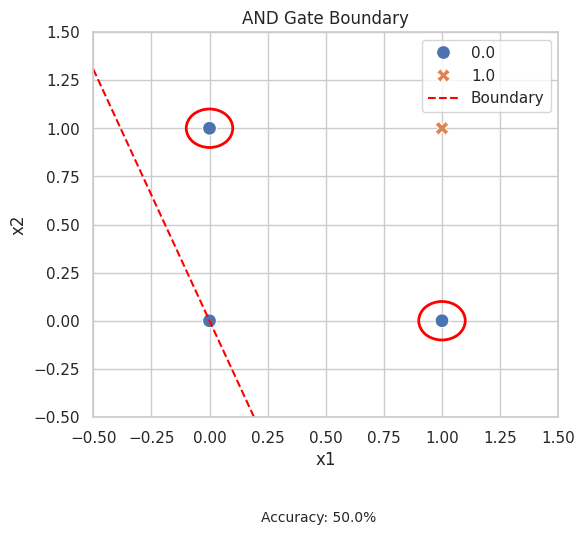

In [10]:
plot_decision_boundary(model, X, y_and, "AND Gate Boundary")

In [11]:
%%html
<div class="todo-box"><h3>TODO</h3></div>

### Question Set 1

1. Run the `plot_decision_boundary` function above, then improve it to address the two `TODO` comments: 
    - Draw a red circle around every instance that is incorrect
    - Include text annotation showing the accuracy as a percentage.

How you do it is up to you. HINT - AI is perfect for these types of well-defined, minor modifications. It's a very cheap prompt.

> This is a perfect use case for AI. This course is designed to maximize your learning outcomes with neural nets and AI, not visualization. Visualiztion in data science is incredibly important, but that's not our emphasis. I will incorporate all levels of general data science in this course at times, and I would expect you to get assistance with AI for non-neural-net topics. This is where some mindfulness and self-awareness must come in. You must remind yourself of what is important for you to learn. An AI Engineer will be "grilled" on demonstrating their understanding of all nuances of neural networks, not making modifications to plots. Thus, in this course only, I would expect AI use for these types of code modifications that are not directly related to the outcomes we're focucsing on. Thus, managing and improving plots and visualizations are perfect use cases for AI. Yes, you want to understand the basics, but making minor modifications to existing code is what AI does best for software development. You can provide a well-defined, simple prompt using the text from my question, and it should generate very good results using the simplest of models. No need for Claude Code level of AI here. 


Congrats! You got through **feedforward** with your first neural network. And you visualized the boundary! But, our model can't learn anything yet! Let's fix that.

## Section 2: Perceptron Learning

The **Perceptron Update Rule** (or **Perceptron Learning Rule**) is based on error correction, enabling the model to learn from mistakes. It's common sense! If your output does not match the target, update your model! If it does make sense, don't update!

For each training example $i$, we compute a measurable **error**:
* $\text{error} = y_{\text{true}} - \hat{y}_{\text{pred}}$

This error guides the **weight and bias update rules**:
* $\mathbf{w}_{\text{new}} = \mathbf{w}_{\text{old}} + \eta \cdot \text{error} \cdot \mathbf{x}$
* $b_{\text{new}} = b_{\text{old}} + \eta \cdot \text{error}$

where $\eta$ (eta) is the **learning rate** (typically a small positive value like 0.1).


### Why Do We Need a Learning Rate?

When we discover that a prediction is wrong, we need to adjust our weights and bias to correct it. But by *how much* should we adjust?

**The Problem:** If we blindly move the decision boundary all the way to the misclassified point, we might overcorrect and misclassify other points. Conversely, if we barely move it, convergence will take forever. You end up in a situation where the model oscillates or converges too slowly.

**The Solution:** The learning rate $\eta$ (eta) acts as a *step size controller*. It scales the magnitude of each weight update, allowing us to find a sweet spot between aggressive learning and stable convergence.

**Intuition:**
- A **high learning rate** (e.g., $\eta = 1.0$) means large jumps in weight space. Fast learning, but risky—we might overshoot the solution and oscillate.
- A **low learning rate** (e.g., $\eta = 0.01$) means tiny, cautious steps. Stable, but slow. The model creeps toward the solution.
- A **moderate learning rate** (e.g., $\eta = 0.1$) offers balance: meaningful progress without wild swings.

> You now have your first **hyperparameter** for training neural networks: **learning rate**.

**Mathematical Justification:**
The learning rate $\eta$ appears as a multiplicative factor that prevents unbounded growth of corrections. Without it, the update rule would be:
* $\mathbf{w}_{\text{new}} = \mathbf{w}_{\text{old}} + \text{error} \cdot \mathbf{x}$
This would shift weights *exactly* to the misclassified input, which is too aggressive, likely causing other instances that were correct to now be misclassified. The learning rate dampens this:
* $\mathbf{w}_{\text{new}} = \mathbf{w}_{\text{old}} + \eta \cdot \text{error} \cdot \mathbf{x}$
Now, the adjustment is proportional to both the error magnitude *and* the step size we choose.

**Intuition behind the update rule:**
- If the prediction is correct (error = 0), weights and bias remain unchanged.
- If the target is 1 but prediction is 0 (error = +1), we add a scaled version of the input to the weights, moving the decision boundary toward the input point.
- If the target is 0 but prediction is 1 (error = −1), we subtract the input from the weights, moving the decision boundary away from the input point.

This simple yet elegant rule demonstrates how learning occurs through incremental corrections based on prediction errors.


### Stepping Through One Update: Single Instance

Let's trace through exactly what happens when the Perceptron learns.

We'll use a sample from the AND gate dataset: $\mathbf{x} = [1, 0]$, which we know has a target $y = 0$. But, we're going to manually modify the weights to ensure the model misclassifies this point.


In [12]:
%%html
<div class="todo-box"><h3>TODO</h3></div>

### Question Set 2

> All code submitted in this course should follow best practices. You are not first-year students. Your functions should be documented using standard Google-style docstrings for every function, which means it has:
> * a description (brief)
> * an **Args** section listing your parameters
> * a **Returns** section, documenting what is returned.<br><br>
> Your function should have good comments making the function easy for you to understands and refer to later. The function below has a docstring for you. And yes, AI can do this for you, and I encourage you to let AI manage your code quality, including documentation! It's another area where the AI-as-a-helper model lets you focus on the hard (and fun) work. Let AI do this stuff.
> <br><br>More complex functions will also have:
> * **Yields** for generator functions
> * **Raises** for any exceptions that this function might raise
> * **Note** for any important notes for developers
> * **Example** showing usage examples. 

This is a pretty simple function, so for this assignment, we'll just stick with **Args** and **Returns**. 

1. Finish the function `create_predictions_table` using the Google-style docstring in the function defintion as your guidance:

In [13]:
def create_predictions_table(model, X, y_actual) -> pd.DataFrame:
    """
    Creates a pandas DataFrame showing X1, X2 input values, y_actual, and y_pred.
    
    Args:
        model: Trained Perceptron model
        X: Input tensor of shape (N, 2)
        y_actual: Actual labels tensor of shape (N,)
    
    Returns:
        pandas DataFrame with columns: X1, X2, y_actual, y_pred
    """

    ##### TODO - Finish the function #####
    y_pred = model.forward(X)
    
    return pd.DataFrame({
        'X1': X[:, 0].numpy(),
        'X2': X[:, 1].numpy(),
        'y_actual': y_actual,
        'y_pred': y_pred,
    })

# Let's try out the function...
results_table = create_predictions_table(model, X, y_and)
results_table


,X1,X2,y_actual,y_pred
0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,1.0
2,1.0,0.0,0.0,1.0
3,1.0,1.0,1.0,1.0


2. Carefully follow the instructions of each step in the code cells below, filling in the missing code. Places to fill in will be clearly commented with a `# TODO` comment. We will use the same AND function as before, with the input tensor `X` and output tensor `y_and`, already defined above. However, we're going to modify the weights and bias of the model so that the point <1,0> is a misclassified instance, outputting a 1 instead of a 0:

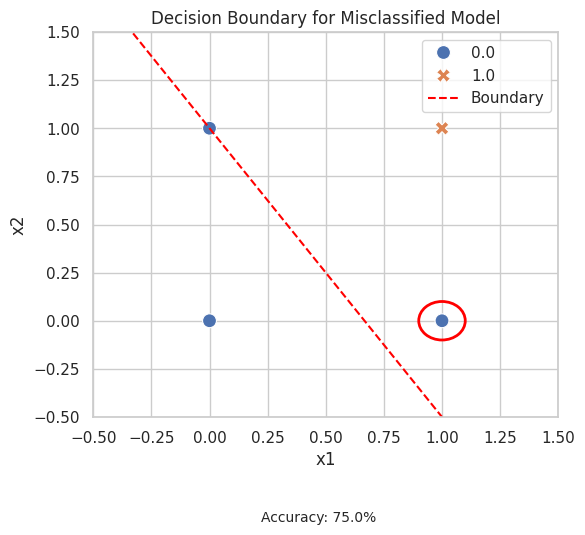

,X1,X2,y_actual,y_pred
0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,1.0
3,1.0,1.0,1.0,1.0


In [14]:
# Initialize a fresh model
model = Perceptron(input_dim=2)
# Modify the weights and bias so that 1,0 is misclassified:
model.weights = torch.tensor([0.3, 0.2])
model.bias = torch.tensor([-0.2])

# TODO - Show the current model's decision boundary and the predictions table to confirm where we're at:
plot_decision_boundary(model, X, y_and, "Decision Boundary for Misclassified Model")
predictions_table = create_predictions_table(model, X, y_and)
predictions_table



Notice that point <1,0> is misclassified. It's supposed to be a 0, but the model predicts a 1.

Complete the update rule below filling in the sections of code denoted

In [15]:
print("Weights before:")
print(f"  Weights: {model.weights}")
print(f"  Bias: {model.bias}")

# TODO 1: Set x_single and y_single to be the single misclassified instance and it's correct target value, respectively.
x_single = torch.tensor(predictions_table.loc[2, ['X1', 'X2']].values)
y_single = torch.tensor(predictions_table.loc[2, 'y_actual'])

# TODO 2: Feedforward - Set y_single_pred to the predicted value of x_single from the model
y_single_pred = torch.tensor(predictions_table.loc[2, 'y_pred'])

# CHECK - print out the predictions for this instance before learning, confirming it's wrong (UNCOMMENT WHEN READY)
print("\nSTEP 1, 2: feedforward")
print(f"  Input x: {x_single}")
print(f"  True label y: {y_single}")
print(f"  Prediction: {y_single_pred}")

Weights before:
  Weights: tensor([0.3000, 0.2000])
  Bias: tensor([-0.2000])

STEP 1, 2: feedforward
  Input x: tensor([1., 0.])
  True label y: 0.0
  Prediction: 1.0


Excellent! If you did it right, you should notice that your predicted and correct values are different! Now let's step through the update rule.

**Refer to the perceptron learning rule above for filling in these sections below:**

In [16]:
# TODO 3: Calculate the error, and print the error amount:
error = y_single - y_single_pred
print(f"Error: {error}")


# TODO 4: Update rule. Use a learning_rate of 0.1. Print the update values
learning_rate = 0.1
update_values = error * learning_rate * x_single
bias_update = error * learning_rate
print(f"Update Vals: {update_values}")


# CHECK - print out the updates to the weights and bias, confirming they are correct (UNCOMMENT WHEN READY)
# print(f"\nSTEP 4: Calculate updates (learning_rate = {learning_rate})")
# print(f"  Weight update = {learning_rate.item():.1f} × {error.item():.1f} × {x_single.tolist()} = {weight_update.tolist()}")
# print(f"  Bias update = {learning_rate.item():.1f} × {error.item():.1f} = {bias_update.item():.4f}")

# TODO 5 - Show the old weights and bias, apply the updates, show the new weights and bias
print(f"Old weights and biases: {model.weights}, {model.bias}")
model.weights += update_values
model.bias += bias_update
print(f"New weights and biases: {model.weights}, {model.bias}")


# TODO 6: Compute the new prediction and verify it's correct
y_single_pred_new = model.forward(x_single.unsqueeze(0))

print(f"\nSTEP 6: Verify the new prediction:")
print(f"\tInput x: {x_single.unsqueeze(0)}")
print(f"\tTrue label y: {y_single.item()}")
print(f"\tOld prediction: {y_single_pred.item()}")
print(f"\tNew prediction: {y_single_pred_new.item()}")
print(f"\tCorrect? {y_single_pred_new == y_single}")




Error: -1.0
Update Vals: tensor([-0.1000, -0.0000])
Old weights and biases: tensor([0.3000, 0.2000]), tensor([-0.2000])
New weights and biases: tensor([0.2000, 0.2000]), tensor([-0.3000])

STEP 6: Verify the new prediction:
	Input x: tensor([[1., 0.]])
	True label y: 0.0
	Old prediction: 1.0
	New prediction: 0.0
	Correct? tensor([True])


3. Show the table and visualize the decision boundary after the update.

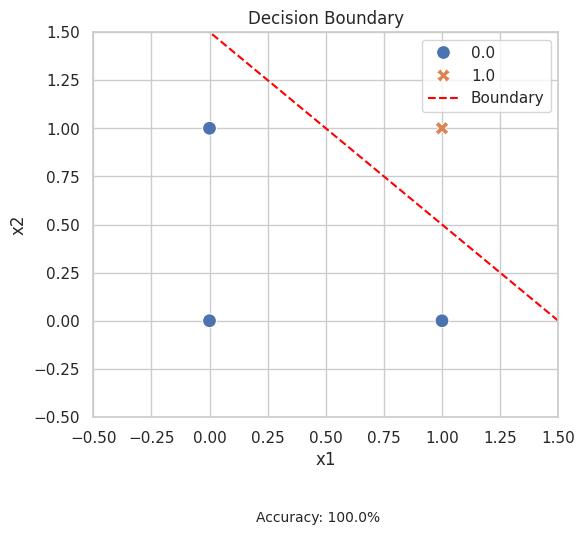

,X1,X2,y_actual,y_pred
0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,1.0,1.0,1.0,1.0


In [17]:
# ANSWER
plot_decision_boundary(model, X, y_and)
predictions_table = create_predictions_table(model, X, y_and)
predictions_table



And, if you did everything right, you should have success! Your last output above in STEP 6 should look something like:

```
Step 6: Verify with new forward pass
  Input x: tensor([[1., 0.]])
  True label y: 0.0
  Old prediction: 1.0
  New prediction: 0.0
  Correct? True
```

### One Misclassified Instance Corrected

We successfully demonstrated the **Perceptron Learning Rule** by manually correcting a single misclassified instance!

#### What We Did
Starting with the point **(1, 0)** that was incorrectly predicted as **1** (when it should be **0**), we:

1. **Identified the Error:** error = 0 − 1 = −1
2. **Applied the Update Rule** with learning rate η = 0.1:
   - Weight update: 0.1 × (−1) × [1, 0] = [−0.1, −0.0]
   - Bias update: 0.1 × (−1) = −0.1
3. **Rotated the Decision Boundary:** Weights shifted from [0.3, 0.2] to [0.2, 0.2], and bias from −0.2 to −0.3
4. **Verified Success:** The same point now correctly predicts **0** ✓

#### Why This Matters
This single correction exemplifies the **core principle of neural network learning**: errors drive adjustments. The Perceptron doesn't memorize. It geometrically repositions its decision boundary based on mistakes. This simple, elegant mechanism laid the foundation for all modern deep learning neural nets. If you got this, you are already understanding the essentials behind training a neural network.

**Summarized:** One misclassified point → one targeted update → the boundary shifts just enough to fix it!


In [18]:
%%html
<div class="todo-box"><h3>TODO</h3></div>

### Question Set 3

The previous question steped through one update of your model for just ONE instance in our data that we knew was incorrect. We need to update based on ALL of our data that are incorrect!

Below is the scaffolding of `train_perceptron`. It sets up a training loop that iterates through each sample in the dataset. We use the term **epoch** to refer to a single pass through the entire dataset when training. An epoch is about figuring out how to adjust the weights and bias to minimize the error. There are generally two ways to do this:

* **Stochastic Gradient Descent (SGD)**: Update weights and bias after each training example within the epoch.
* **Batch Gradient Descent**: Accumulate the weight and bias updates for all samples first, then update weights and bias after the epoch is complete. We'll discuss this more in the next section.

> Ignore "Gradient Descent" for now. We'll discuss that more very soon!

1. In our code below, we're going to take the SGD approach and update the weights after every instance. Carefully analyze the code and the comments below, paying close attention to each `# TODO` comment, and complete the code!

> Notice your second hyperparameter - **epochs**. This is the number of times you will iterate through the entire dataset and update your model.

> Notice the Google-style docstring for the function. These are required for every function you write. 

In [19]:
def train_perceptron(model, X, y, learning_rate=0.1, epochs=20):
    """Fits a perceptron model on the provided training data via stochastic updates.
    
    Args:
        model: The perceptron instance to be trained. Must have 'weights', 'bias', and a 'forward' method.
        X (torch.Tensor): Input feature tensor of shape (n_samples, n_features).
        y (torch.Tensor): Target labels tensor of shape (n_samples,).
        learning_rate (float): The step size for weight/bias updates.
        epochs (int): Number of passes over the entire training dataset.
        
    This function iterates through the dataset for a specified number of epochs, applying the Perceptron 
    Learning Rule:
            w := w + η (target - predicted) * x
            b := b + η (target - predicted)
    after each training example. If the total error reaches zero, training stops early (convergence).
    """
    print("Starting training...")

    # Iterate through a specified number of epochs
    for epoch in range(epochs):
        # Let's accumulate the absolute value of the error to see if we're improving our error as we progress
        total_error = 0

        # We're following the SGD approach, thus in the loop, perform the perceptron update rule for each sample
        for i in range(X.shape[0]):

            # TODO 1: Grab the input tensor and correct output for the ith instance
            x_single = X[i, :]
            y_actual = y[i]

            # TODO 2. Feed forward the instance through the model
            y_pred = model.forward(x_single)

            # TODO 3. Calculate error 
            error = y_actual - y_pred

            # TODO 4. Compute Weights and Bias adjustments
            delta_weight = error * learning_rate * x_single
            delta_bias = error * learning_rate

            # TODO 5. Apply the updates to your model weights and bias
            model.weights += delta_weight
            model.bias += delta_bias

            # TODO 6. Accumulate the absolute value of the error in total_error
            total_error += torch.abs(error)


        print(f"Epoch {epoch}: Total Errors = {int(total_error.item())}")

        # STEP 7. IF there is no error, then stop. 
        if total_error == 0:
            print(f"Converged at epoch {epoch}!")
            break

    print("Training complete.")



2. Instantiate a new model. Output the decision boundary before training. Call your new train_perceptron function on your new model, passing the same AND data we've been using. Output the decision boundary after.

Model weights, bias, and prediction BEFORE training: tensor([-1.1229, -0.1863]), tensor([0.]), tensor([0., 0., 0., 0.])


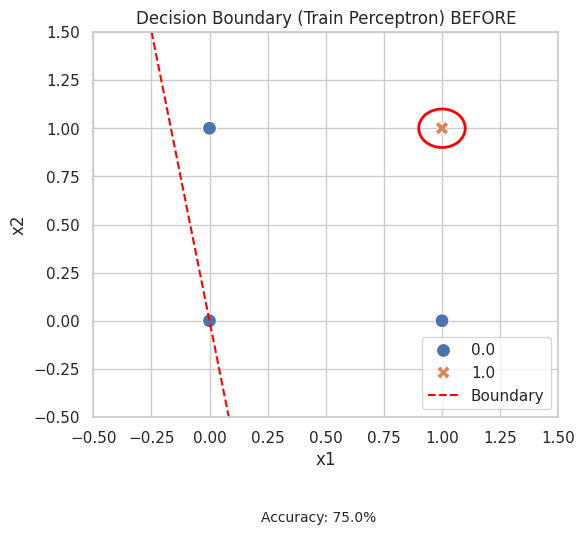

Starting training...
Epoch 0: Total Errors = 1
Epoch 1: Total Errors = 2
Epoch 2: Total Errors = 3
Epoch 3: Total Errors = 2
Epoch 4: Total Errors = 2
Epoch 5: Total Errors = 2
Epoch 6: Total Errors = 2
Epoch 7: Total Errors = 2
Epoch 8: Total Errors = 2
Epoch 9: Total Errors = 2
Epoch 10: Total Errors = 2
Epoch 11: Total Errors = 2
Epoch 12: Total Errors = 2
Epoch 13: Total Errors = 3
Epoch 14: Total Errors = 2
Epoch 15: Total Errors = 2
Epoch 16: Total Errors = 3
Epoch 17: Total Errors = 2
Epoch 18: Total Errors = 1
Epoch 19: Total Errors = 0
Converged at epoch 19!
Training complete.


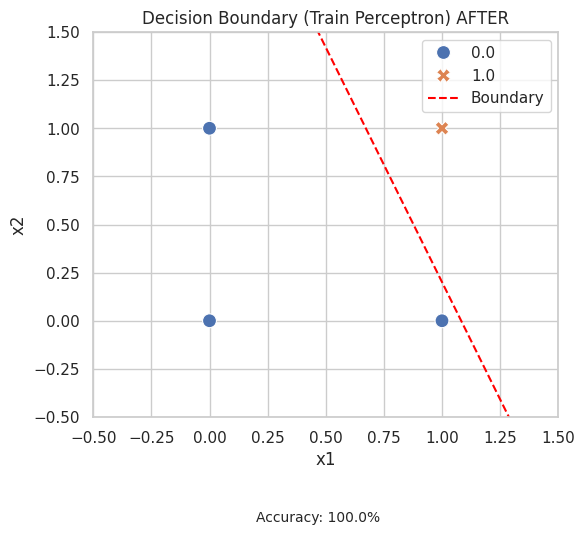

Model weights and bias AFTER training: tensor([0.2771, 0.1137]), tensor([-0.3000]), tensor([0., 0., 0., 1.])


In [20]:
# Re-initialize model to start fresh
model = Perceptron(input_dim=2)

# TODO - Print the weight, bias and predictions before training
print(f"Model weights, bias, and prediction BEFORE training: {model.weights}, {model.bias}, {model.forward(X)}")


# TODO - Output the decision boundary before training, train your model, then output the decision boundary after training
plot_decision_boundary(model, X, y_and, "Decision Boundary (Train Perceptron) BEFORE")
train_perceptron(model, X, y_and)
plot_decision_boundary(model, X, y_and, "Decision Boundary (Train Perceptron) AFTER")

# TODO - Print out the final weights, bias, and predictions
print(f"Model weights and bias AFTER training: {model.weights}, {model.bias}, {model.forward(X)}")




## Section 3: From Sample Updates to Batch Updates

Up to this point, we've performed perceptron weight updates after processing each individual data point; this is known as **Stochastic Gradient Descent (SGD)** as applied to the Perceptron. In other words, we update the model's weights and bias after processing each sample (also called an "online" or "sample-wise" update).

> You probably recognize that we haven't defined **gradient descent** yet. Maybe you saw it if you took a multivariate calculus course or a course that covered partial derivatives. For now, understand that it's a technique for finding values over multiple variables that minimize a function. We're trying to minimize the error over all of our input variables and weights. When you think minimization, even if gradient descent isn't familiar, hopefully you are thinking about taking derivatives of the equation you want to find where in its domain it achieves a minimum. Even neglecting the formalities, think logically - we need to explore the space of weights and biases to find where the error is minimized! And that's precisely what gradient descent does.

In modern machine learning and deep learning, it's *usually* more efficient and effective to update model parameters after processing a group of samples together. This approach is called **batch learning** when you use the whole dataset at once, or **mini-batch learning** when you use a small subset of the data. If a batch contains only a single sample, it's equivalent to the SGD approach we used earlier; if it contains all samples, it's a "full batch".

### **Why process data in batches?**

1. **Computational Efficiency:** Many hardware accelerators (like GPUs) can perform matrix operations on many data points at once, leading to dramatic speed-up compared to looping through samples one at a time.
2. **Learning Stability:** Averaging errors across a batch can smooth out the "noisy" updates that happen when you update parameters using individual samples. This often leads to better, more stable training.

Let's now derive and implement the perceptron learning rule using batches. Instead of updating weights for just one sample, we'll use all errors from the batch to compute a *single* update. 

As usual, we'll define the following:
* $\mathbf{X}$ is our dataset. It's a matrix of shape $(N, D)$ (with $N$ samples and $D$ features).
* $\mathbf{y}$ is the vector of target values for all samples. It's a vector of length $N$
* $\mathbf{\hat{y}}$ is the vector of predicted target values, also a vector of length $N$
* $\mathbf{w}$ is a vector of weights of length $D$, i.e. a weight for each input into the perceptron
* $b$ is the bias for our perceptron, i.e a scalar value
* $\eta$ is our learning rate, $(0.0 - 1.0)$, default to $0.1$

First, we compute the predicted values of all samples in $\mathbf{X}$ from the model:

* $\mathbf{\hat{y}} = \mathbf{w} X + b$

Using that, we can compute the error:
* $\mathbf{error} = \mathbf{y} - \mathbf{\hat{y}}$

Once we have the error, we can compute a small adjustment to apply to the weights and bias:
* $\mathbf{w}_{adj} = \eta \cdot (\mathbf{X}^T \cdot \mathbf{error})$
* $b_{adj} = \eta \cdot \sum_{i=1}^N \text{error}_i$

And... make the adjustment:
* $\mathbf{w} = \mathbf{w} + \mathbf{w}_{adj}$
* $b = b + b_{adj}$

That's one epoch! You'll repeat this some number of epochs.

In [21]:
%%html
<div class="note-box"><h1>IMPORTANT</h1><div>

> If you're asked about the "pain point" of perceptron training, which operation above do you think is the most costly and why? Hopefully, you identified $\mathbf{X}^T \cdot \mathbf{error}$. It is a key operation that uses matrix multiplication to compute the weight adjustment vector in one operation. This is an operation that could literallly be repeated millions of times for real-world large network training with large datasets. $\text{error}_i \cdot x_i$ over all samples, producing a single weight update. But, GPUs are fantastic at basic matrix operations, and is why GPUs are fundamental to making LLMs a reality. 


Here, $\mathbf{X}^T \cdot \mathbf{error}$ sums up $\text{error}_i \cdot x_i$ over all samples, producing a single weight update. This vectorized approach is both fast and more reflective of how modern neural networks are trained.

In [22]:
%%html
<div class="todo-box"><h3>TODO</h3></div>

### Question Set 4

1. Below is the scaffolding for batch training a perceptron. Now, you have two hyperparameters - `learning_rate` and `epochs`. As usual, complete each section labeled `# TODO`. Write a Google-style docstring for your function.

In [23]:
def train_perceptron_batch(model, X, y, learning_rate=0.01, epochs=100):
    # TODO - Write a Google-style docstring for your function
    """
    Trains a perceptron model using batch gradient descent.
    
    This function performs batch updates by processing all training samples simultaneously
    in each epoch. Unlike stochastic gradient descent (which updates after each sample),
    batch gradient descent computes the average gradient over the entire dataset before
    updating weights and bias.
    
    The batch update rule:
        w := w + η · Σ(error_i · x_i)
        b := b + η · Σ(error_i)
    
    Args:
        model: The perceptron instance to be trained. Must have 'weights', 'bias', 
            and a 'forward' method.
        X (torch.Tensor): Input feature tensor of shape (n_samples, n_features).
        y (torch.Tensor): Target labels tensor of shape (n_samples,).
        learning_rate (float, optional): The step size for weight/bias updates. 
            Defaults to 0.01.
        epochs (int, optional): Number of passes over the entire training dataset. 
            Defaults to 100.
    
    Returns:
        None: The model is updated in-place.
    
    Note:
        Training stops early if the model achieves zero error (perfect classification)
        on the training set.
    """
    print("Starting batch training...")

    # Print the training parameters
    print(f"Training parameters: learning_rate={learning_rate}, epochs={epochs}")
    
    
    for epoch in range(epochs):
        # TODO 1. feedforward all of our data using the model's forward method
        total_error = 0
        y_pred = model.forward(X)

        # TODO 2. Calculate error vector
        error = y - y_pred

        # TODO 3. Compute the weight updates
        # Use matrix multiplication for the weights update
        # X is (N, D), error is (N). Result should be (D).
        delta_weight = torch.matmul(X.T, error)


        # TODO 4. Apply the updates to your model weights and bias
        model.weights += (delta_weight * learning_rate)
        model.bias += (torch.sum(error) * learning_rate)


        # TODO 5. Accumulate the absolute value of the error in total_error and print it along with the accuracy so far
        total_error += torch.sum(torch.abs(error))
        accuracy = (y_pred == y).float().mean().item() * 100
        print(f"Epoch {epoch}: Total Error = {total_error.item()}, Accuracy = {accuracy}")


        # TODO 6. IF there is no error, then stop. (UNCOMMENT WHEN READY)
        if total_error == 0:
            print(f"Converged at epoch {epoch}!")
            break


2. Write code to instantiate a new perceptron, output the decision boundary before training, call your new `train_perceptron_batch` to train it, and output an updated decision boundary after training. 

The output of your function above should look something like this (where your actual number of epochs and error rate will vary with each run):
```
Starting batch training...
Training parameters: learning_rate=0.25, epochs=100
Epoch 0: Total Errors = 2 | Accuracy = 50.00%
Epoch 1: Total Errors = 2 | Accuracy = 50.00%
Epoch 2: Total Errors = 1 | Accuracy = 75.00%
Epoch 3: Total Errors = 1 | Accuracy = 75.00%
Epoch 4: Total Errors = 1 | Accuracy = 75.00%
Epoch 5: Total Errors = 1 | Accuracy = 75.00%
Epoch 6: Total Errors = 2 | Accuracy = 50.00%
Epoch 7: Total Errors = 1 | Accuracy = 75.00%
Epoch 8: Total Errors = 0 | Accuracy = 100.00%
Converged at epoch 8!
```

Play with the `epoch` and `learning_rate` parameters. Run it multiple times to compare your results. Then, comment on your findings. 

Model weights, bias, and prediction BEFORE training: tensor([ 2.2082, -0.6380]), tensor([0.]), tensor([0., 0., 1., 1.])


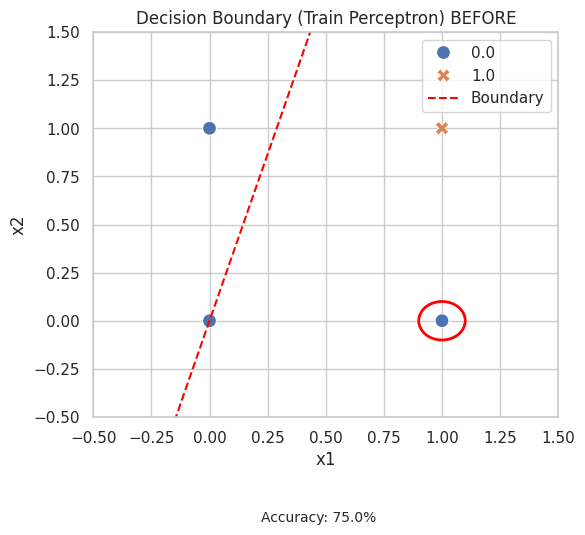

Starting batch training...
Training parameters: learning_rate=0.25, epochs=100
Epoch 0: Total Error = 1.0, Accuracy = 75.0
Epoch 1: Total Error = 1.0, Accuracy = 75.0
Epoch 2: Total Error = 1.0, Accuracy = 75.0
Epoch 3: Total Error = 1.0, Accuracy = 75.0
Epoch 4: Total Error = 2.0, Accuracy = 50.0
Epoch 5: Total Error = 2.0, Accuracy = 50.0
Epoch 6: Total Error = 1.0, Accuracy = 75.0
Epoch 7: Total Error = 1.0, Accuracy = 75.0
Epoch 8: Total Error = 1.0, Accuracy = 75.0
Epoch 9: Total Error = 1.0, Accuracy = 75.0
Epoch 10: Total Error = 1.0, Accuracy = 75.0
Epoch 11: Total Error = 0.0, Accuracy = 100.0
Converged at epoch 11!


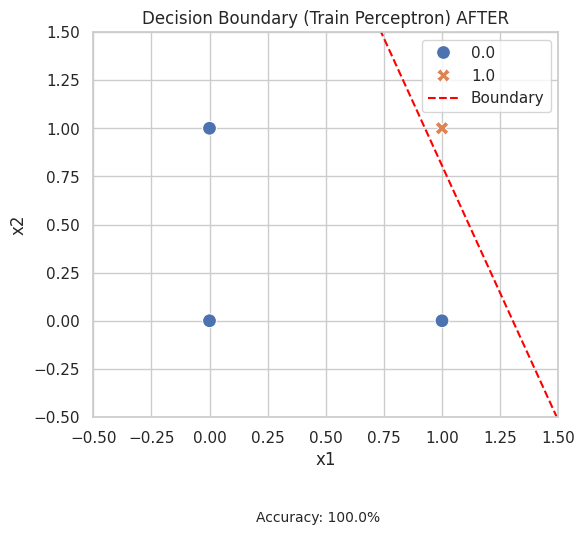

Model weights and bias AFTER training: tensor([0.9582, 0.3620]), tensor([-1.2500]), tensor([0., 0., 0., 1.])


In [24]:
# ANSWER

model = Perceptron(input_dim=2)

# TODO - Print the weight, bias and predictions before training
print(f"Model weights, bias, and prediction BEFORE training: {model.weights}, {model.bias}, {model.forward(X)}")


# TODO - Output the decision boundary before training, train your model, then output the decision boundary after training
plot_decision_boundary(model, X, y_and, "Decision Boundary (Train Perceptron) BEFORE")
train_perceptron_batch(model, X, y_and, learning_rate=0.25, epochs=100)
plot_decision_boundary(model, X, y_and, "Decision Boundary (Train Perceptron) AFTER")

# TODO - Print out the final weights, bias, and predictions
print(f"Model weights and bias AFTER training: {model.weights}, {model.bias}, {model.forward(X)}")







**ANSWER:** It seems that a higher learning_rate leads to a faster convergence towards the local minimum. Another interesting thing to note is that accuracy can decrease through subsequent epochs. A high epoch is also not needed as it seems to be able to converge well below 100 epochs.

Comment on your findings above. You should have found that you can increase the `learning_rate` quite a bit on this simple dataset!


## Section 4: The Iris Dataset

Logic gates are "toy" problems. Let's try something slightly more realistic. We'll use a subset of the famous **Iris Dataset**.

> The Iris dataset is a classic dataset in machine learning and statistics, introduced by the British biologist and statistician Ronald Fisher in 1936. 
It consists of 150 samples of iris flowers, with each sample described by four features: sepal length, sepal width, petal length, and petal width. 
The goal is to classify each sample into one of three species: Setosa, Versicolor, or Virginica. 
Yes, it's incredibly overused, but for a reason - it is well-structured and easily visualized, making it ideal for basic classification 
techniques and testing simple machine learning models. 

We will first try to distinguish between **Setosa** and **Versicolor** using only two features: Sepal Length and Petal Length.

In [25]:
# Load the class Iris dataset from sklearn
from sklearn.datasets import load_iris

# Let's look at the first few lines
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
del iris
df_iris.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Let's filter for only two classes (0: Setosa, 1: Versicolor). They are well-separated classes, and it turns this into a binary classification problem. To keep it reasonable for one perceptron, we'll use only two features: sepal length (0) and petal length (2), so we can still visualize the boundary.

Let's set up our input data and target variables. We'll call them `X_iris` and `y_iris`, respectively:

In [26]:
# Select only classes 0 (Setosa) and 1 (Versicolor)
df_iris_subset = df_iris[df_iris['target'] < 2][['sepal length (cm)', 'petal length (cm)', 'target']]

# Subset the data that we want to work with, converting the data to tensors
X_iris = torch.tensor(df_iris_subset[['sepal length (cm)', 'petal length (cm)']].values, dtype=torch.float32)
y_iris = torch.tensor(df_iris_subset['target'].values, dtype=torch.float32)

In [27]:
%%html
<div class="note-box"><h3>IMPORTANT - Standardizing data</h3></div>

### Should you normalize or standardize data for neural networks?

Most methods in machine learning require you to perform some type of rescaling of your features to ensure no individual feature is dominating the input. There are a variety of ways you can do this. In the context of neural networks, **standardization** is generally preferred over normalization. Here’s the difference:

- **Normalization** is a more general term, where you typically rescale data to a fixed range, such as [0, 1] or [-1, 1] (for example, using min-max scaling). There is also L2 Normalization, where you rescale each input vector to have a unit length of 1. We will revisit this when we look at word embeddings later in the course.
- **Standardization** is a type of normalization. It transforms each feature by subtracting its mean and dividing by its standard deviation, so the feature has a mean of 0 and a standard deviation of 1. This is also known as **z-score normalization**.

Either approach can be used, but in most machine learning methods, **standardization** is usually the preferred practice. 

**Why is this so important for neural networks?**

Neural networks are sensitive to the scale and distribution of input features. If the inputs are on very different scales, the model may:

- Converge much more slowly or fail to converge at all
- Produce unstable gradients, making training harder
- Struggle to find a balance in learning weights associated with features of very different magnitudes, always preferring adjustments of weights for the inputs that are huge. BAD!

Standardizing each feature ensures that all inputs contribute more equally during training. It makes the optimization (training) process more stable and helps the network learn more efficiently—especially when using activation functions like sigmoid or tanh that can saturate for large input values.

**Are there any rules for choosing standardization vs. other normalization techniques?**
Great question! There is no strict rule of thumb for which normalizaton technique to use. With experience, you'll learn which techniques are best under which situations. There are times this really matters... a lot! For instance, we'll soon learn about activation functions such as sigmoid or hyperbolic tangent that have very strict, limited output range, where you would be creating problems if you used standardization on the output layer data!

In [28]:
%%html
<div class="todo-box"><h3>TODO</h3></div>

### Question Set 5
1. Fill in the code below, paying attention to every `# TODO` comment.

> The first step has you create a standardized form of X_iris. You could use sklearn's `StandardScaler`, but I prefer to stick with pure PyTorch, as I would have to convert the result back to a tensor, adding an additional step. Just use standard tensor ops.

In [29]:
# TODO: Standardize X_iris, naming the variable X_iris_std.
X_iris_std = (X_iris - torch.mean(X_iris, dim=0)) / torch.std(X_iris, dim=0)

# TODO: Print the shape of X_iris
print(X_iris.shape)

# TODO: Show the first 5 rows of the standardized data
print(X_iris_std[:5])


torch.Size([100, 2])
tensor([[-0.5782, -1.0079],
        [-0.8898, -1.0079],
        [-1.2015, -1.0769],
        [-1.3573, -0.9389],
        [-0.7340, -1.0079]])


2. Instantiate a new Perceptron called `model_iris`, plot the decision boundary on `X_iris_std`, train the model using the batch training function. Use a learning rate of 0.01. Then plot the decision boundary after training.

Model weights, bias, and prediction BEFORE training: tensor([0.9582, 0.3620]), tensor([-1.2500]), tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0.,
        1., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0.,
        1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 1., 0., 0.])


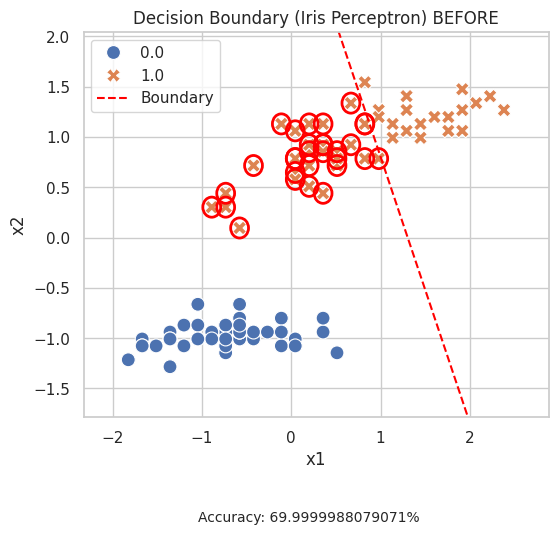

Starting batch training...
Training parameters: learning_rate=0.25, epochs=100
Epoch 0: Total Error = 30.0, Accuracy = 69.9999988079071
Epoch 1: Total Error = 9.0, Accuracy = 91.00000262260437
Epoch 2: Total Error = 0.0, Accuracy = 100.0
Converged at epoch 2!


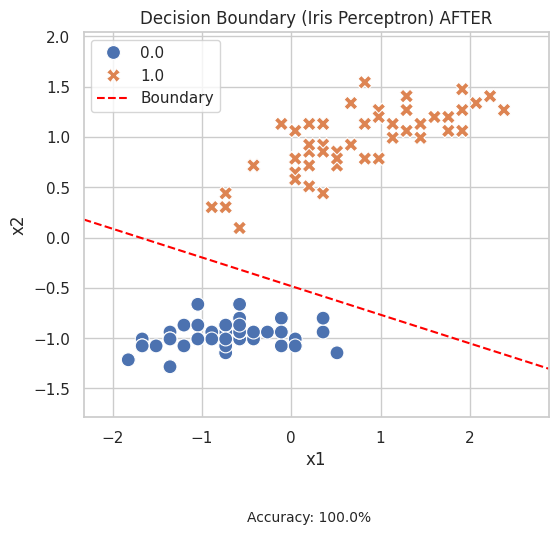

Model weights and bias AFTER training: tensor([2.3642, 8.2988]), tensor([4.]), tensor([1., 1., 1., 1.])


In [30]:
# Train on Iris
model_iris = Perceptron(input_dim=2)

# TODO - Print the weight, bias and predictions before training
print(f"Model weights, bias, and prediction BEFORE training: {model.weights}, {model.bias}, {model.forward(X_iris_std)}")


# TODO - Output the decision boundary before training, train your model, then output the decision boundary after training
plot_decision_boundary(model, X_iris_std, y_iris, "Decision Boundary (Iris Perceptron) BEFORE")
train_perceptron_batch(model, X_iris_std, y_iris, learning_rate=0.25, epochs=100)
plot_decision_boundary(model, X_iris_std, y_iris, "Decision Boundary (Iris Perceptron) AFTER")

# TODO - Print out the final weights, bias, and predictions
print(f"Model weights and bias AFTER training: {model.weights}, {model.bias}, {model.forward(X)}")




Excellent! You now see how one single perceptron can do quite a bit... as long as the data are **linearly separable**. The Challenges below will delve deeper, allowing you to explore a multiclass problem on data that just aren't quite linearly separable!

In [31]:
%%html
<div class="section-box">
<h1></h1>
</div>

# <div class="section-box">Challenges</div>

In [32]:
# Define XOR data
X_xor = torch.tensor([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
], dtype=torch.float32)

y_xor = torch.tensor([0., 1., 1., 0.], dtype=torch.float32)

## 1. The XOR Problem (The "AI Winter" Trigger)

The classic problem always used to demonstrate the limitations of a linear model is Exclusive-OR, or XOR. In 1969, Minsky and Papert published "Perceptrons", proving that a single-layer perceptron cannot solve the XOR (Exclusive OR) problem. (Yes, it took that long from the original Perceptron to develop the mathematical framework that proves the obvious.) This proof contributed to a decline in neural network research for over a decade! Fascinating, right? Next week, when we delve into the Multi-layer perceptron, it'll make more sense.

**Your Task:**
I defined a tensor representing the XOR function above. Your job is to:
1. Instantiate a new `Perceptron` and plot the decision boundary on `X_xor`.
2. Train it using your `train_perceptron_batch` function using the `X_xor` and `y_xor` defined above. Explore different parameters for learning rate and epochs, though I wouldn't bother with anything above 50. (It can't be solved!)
2. Plot the decision boundary after training.
3. **Analysis:** In the markdown cell below the code, explain *why* the Perceptron fails. Use the term **"Linearly Separable"** in your answer.

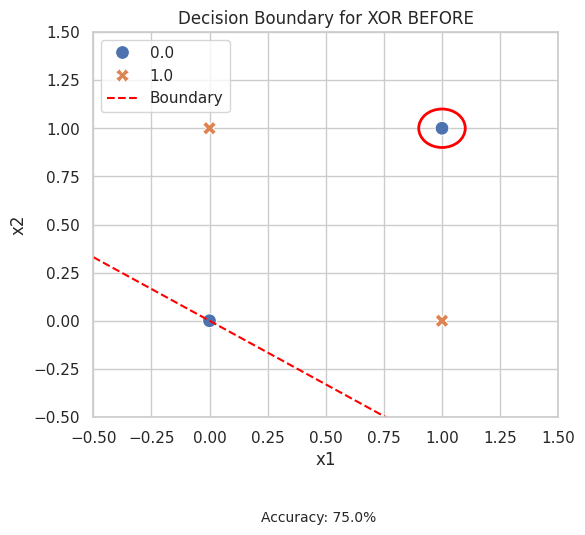

Starting batch training...
Training parameters: learning_rate=0.1, epochs=50
Epoch 0: Total Error = 1.0, Accuracy = 75.0
Epoch 1: Total Error = 1.0, Accuracy = 75.0
Epoch 2: Total Error = 1.0, Accuracy = 75.0
Epoch 3: Total Error = 2.0, Accuracy = 50.0
Epoch 4: Total Error = 2.0, Accuracy = 50.0
Epoch 5: Total Error = 2.0, Accuracy = 50.0
Epoch 6: Total Error = 3.0, Accuracy = 25.0
Epoch 7: Total Error = 1.0, Accuracy = 75.0
Epoch 8: Total Error = 2.0, Accuracy = 50.0
Epoch 9: Total Error = 1.0, Accuracy = 75.0
Epoch 10: Total Error = 3.0, Accuracy = 25.0
Epoch 11: Total Error = 1.0, Accuracy = 75.0
Epoch 12: Total Error = 2.0, Accuracy = 50.0
Epoch 13: Total Error = 1.0, Accuracy = 75.0
Epoch 14: Total Error = 2.0, Accuracy = 50.0
Epoch 15: Total Error = 2.0, Accuracy = 50.0
Epoch 16: Total Error = 2.0, Accuracy = 50.0
Epoch 17: Total Error = 2.0, Accuracy = 50.0
Epoch 18: Total Error = 2.0, Accuracy = 50.0
Epoch 19: Total Error = 2.0, Accuracy = 50.0
Epoch 20: Total Error = 2.0, Accu

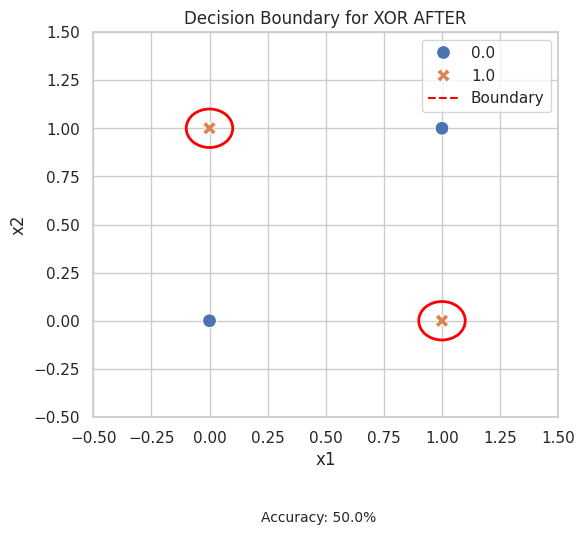

In [33]:
# ANSWER - Code

model = Perceptron(input_dim=2)

plot_decision_boundary(model, X_xor, y_xor, "Decision Boundary for XOR BEFORE")

train_perceptron_batch(model, X_xor, y_xor, learning_rate=0.1, epochs=50)

plot_decision_boundary(model, X_xor, y_xor, "Decision Boundary for XOR AFTER")



**ANSWER**
The perceptron fails here because the data defining the XOR logic gate is not linearly separable. If we look at the decision boundary, we cannot draw a line that separates the two types of answers (binary classification). In other words, the data is not easily classifiable by a linear model like the perceptron.






## 2. Implement a **"One vs. Rest"** classifier with multiple perceptrons

A perceptron is fantastic for simple 2-class (i.e. binary class) problems. What do you do if you have a problem that requires predicting more than one binary output? A **One vs. Rest** classifier is a method to extend binary classifiers so that they can solve multiclass problems.

If you have $K$ classes, you need to train $K$ separate binary classifiers, where each classifier is trained to predict ONE target output, thus viewing all other classes as "the rest". Each model is responsible for answering the question: "Is this input an example of class $k$ or not?" When predicting, every classifier gives a score for each class, and the class with the highest score is chosen! Simple!

### Why is this needed for the Iris dataset?

The Iris dataset contains *three* different flower species (three classes). Since a single Perceptron can only distinguish between two classes, we need to combine several Perceptrons to be able to classify all three at once. The 1 vs. Rest strategy lets us do this by constructing a Perceptron for each class.

Let's reload the iris dataset to restore all variables, and look at a **pair plot** (or a scatter plot matrix) that shows all pairs of features in a dataset, while using color to distinguish the target class:

In [34]:
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
# Map the integer target labels to target names for better plotting
df_iris['target_name'] = df_iris['target'].map(dict(enumerate(iris.target_names)))
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


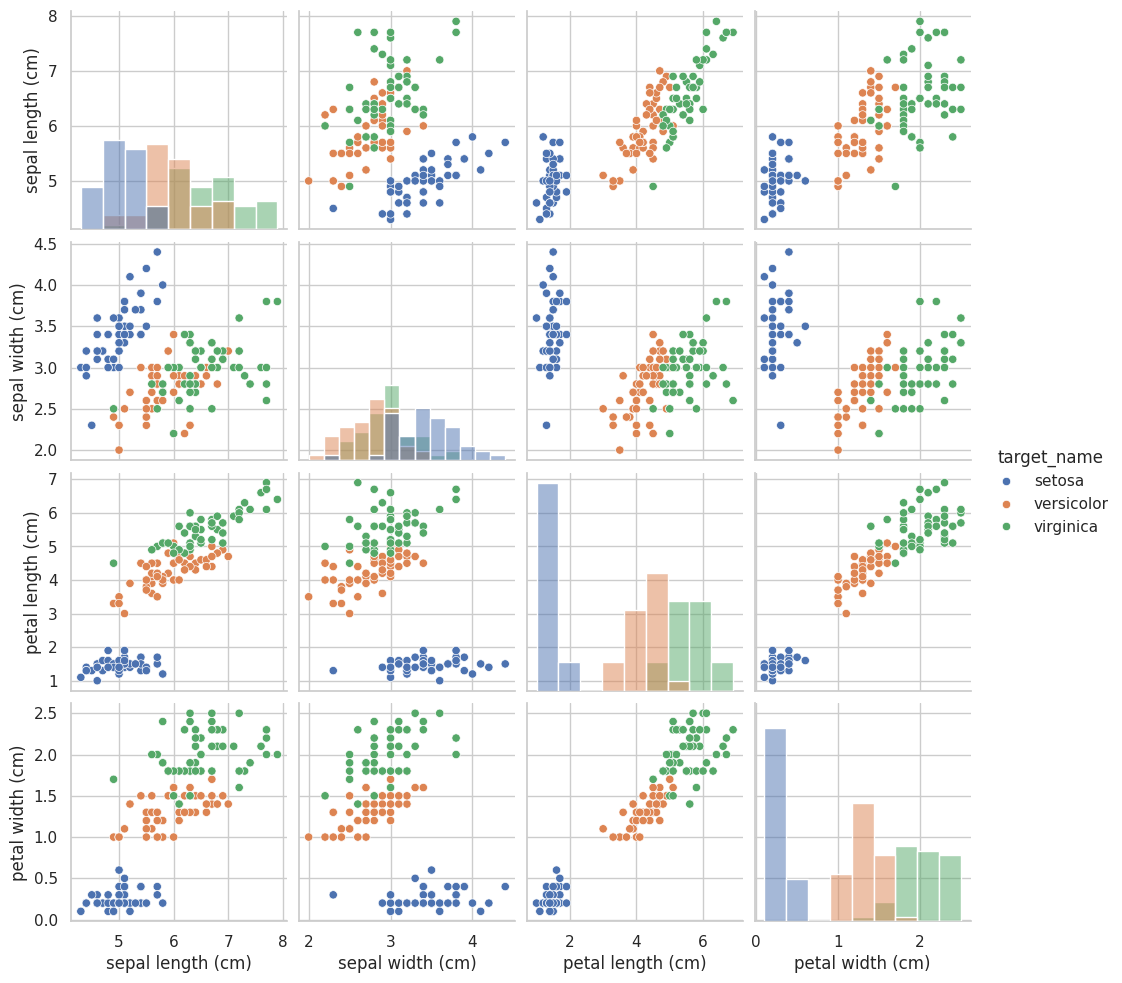

In [35]:
sns.pairplot(df_iris.drop(columns=['target']), hue='target_name', diag_kind='hist')

> If you've had any interest in machine learning at all (or if you've taken my CSCI 349 course :-) ), you've seen these data before. Setosa is clearly well-separated from the other classes. However, there is some overlap between versicolor and virginica. But, the bigger point - a single perceptron can't be used to model these data! There are three classes. You're going to implement a **One vs. Rest Perceptron**.

### One Hot Encoding

We know that a single perceptron can only output a binary value (0 or 1). We will need a perceptron for each class whose output aligns with the restricted output of our perceptrons. This will be true throughout the course! **Always be mindful of the output range of your last layer of your neural net, as you'll need to be sure the distribution of your output data matches the output layer of your network.** How do we set up our data to make this easy? We need to encode our output variable as a binary-encoded vector, where each element is 1 if the corresponding class is present in the sample, 0 otherwise.

**One-hot encoding** is a process used to represent categorical data as binary vectors. In a multi-class classification problem with $K$ classes, each class is represented by a vector of length $K$ where only the index corresponding to the specific class is $1$ (the "hot" bit), and all other indices are $0$.
> You will also see the term **binary encoding**, **binary encoded vectors**, and **indicator variables**, and **indicator vector** used interchangeably.

For example, in the Iris dataset with three classes (Setosa, Versicolor, Virginica), there is one target variable, named df_iris['target'], whose values from the set [0,1,2], using integers to represent each class, Setosa, Versicolor, and Virginica, respectively. A binary encoded vector for this target variable would look like this:

- **Setosa**: `[1, 0, 0]`
- **Versicolor**: `[0, 1, 0]`
- **Virginica**: `[0, 0, 1]`

#### Why use it for Neural Networks?
1. **Removes Implicit Ordering**: If we used simple integers (0, 1, 2) to represent classes, a neural network might mistakenly assume that Class 2 is "greater than" or "further from" Class 0. One-hot encoding treats all classes as equidistant in the feature space.
2. **Probability Distribution Output**: Neural networks typically use a **Softmax layer** at the end to transform the output into a probability distribution over classes. One-hot targets provide a perfect target distribution (100% confidence for the correct class) that can be compared against the model's predicted probabilities using loss functions like Cross-Entropy.
3. **Compatibility with One-vs-Rest**: As seen in our implementation, it allows us to easily isolate the target for individual binary classifiers (perceptrons) within a multi-class system.

### How to One-Hot Encode a Target Variable
Generally, there are two approaches:
* `pd.get_dummies()` - This function creates a new column for each category in the target variable, effectively one-hot encoding the data. This works great if your data are contained in a pandas DataFrame and you want a quick and easy solution.
* `sklearn.preprocessing.OneHotEncoder` - This class provides more control over the encoding process, including handling sparse matrices and customizing the output format. This one has a bit more flexibility, but if your data are in a pandas DataFrame, `pd.get_dummies()` is probably easier to use.

### Best Practices: Start with setting up your data as `X` and Output `y`

In machine learning, it is a standard convention to denote your input feature matrix as **`X`** and your target labels as **`y`**. This stems from the mathematical notation $y = f(X)$.

When your project has multiple datasets, it's a good idea to use meaningful variable names for your data to avoid confusion. We'll use `X_iris` and `y_iris` for the Iris dataset.

In this case, because we are dealing with three species of Iris, our output will actually be a matrix with three columns (one for each class). To remind ourselves of this structure, we will name our target variable **`y_iris_ohe`**. This signifies that the labels have been transformed using **One-Hot Encoding**.

We will set this up for you this first time, understanding you'll need to do this for every dataset you encounter in the future.

In [36]:
# Sanity check for the dev... let's delete generic variables
del X

# Create the X_iris data frame with the four iris features
X_iris = df_iris.iloc[:,:4]

# Create the one-hot encoded target data frame y_ohe
# pd.get_dummies converts categorical variables into dummy/indicator variables of type bool
y_iris_ohe = pd.get_dummies(df_iris['target'], prefix='class')

# Display the shapes and first few rows to verify
print(f"X shape: {X_iris.shape}")
print(f"y_ohe shape: {y_iris_ohe.shape}")
print(X_iris.head())
print(y_iris_ohe.head())

X shape: (150, 4)
y_ohe shape: (150, 3)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
   class_0  class_1  class_2
0     True    False    False
1     True    False    False
2     True    False    False
3     True    False    False
4     True    False    False



#### Instructions

1. **Define a `OnevsRestPerceptron` class:**<br>
   This class should bundle multiple Perceptron objects—one for each class (so, three for Iris). This allows each Perceptron to learn how to predict one class against all the other classes. Follow the instructions for the methods in the class:


In [37]:
# ANSWER:
class OneVsRestPerceptron:
    """One vs. Rest Perceptron classifier for multiclass classification.
    
    This class implements a multiclass classification strategy. All perceptrons compute
    their logits for their respective classes. The highest logit is determined to be
    the predicted class.
    
    Attributes:
        input_dim (int): The dimensionality of the input features.
        num_classes (int): The number of classes to predict.
        perceptrons (list): A list of Perceptron objects, one per class.    
    """

    def __init__(self, input_dim, num_classes):
        """Initialize the One vs. Rest Perceptron classifier.
        
        Creates a separate binary Perceptron classifier for each class in the
        multiclass problem. Each perceptron will be trained to distinguish its
        assigned class from all other classes combined.
        
        Args:
            input_dim (int): The number of input features. Must be a positive integer.
            num_classes (int): The number of classes to classify. Must be >= 2.        
        """
        # TODO 1. Complete the constructor
        # Validation check
        if input_dim < 1 or num_classes < 2:
            raise Exception("OneVsRestPerceptron initialization failed. Make sure arguments are valid")
        
        # Initialize perceptron list
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.perceptrons = [Perceptron(self.input_dim) for _ in range(self.num_classes)]


    def logits(self, X):
        """Feed X through each perceptron and return the logits

        Args:
            X (torch.Tensor): A tensor of input features of shape (N, input_dim).

        Returns:
            torch.Tensor: A tensor of logits of shape (N, num_classes).
        """
        # TODO 2. Complete the logits method
        all_logits = []
        for perceptron in self.perceptrons:
            perceptron_logit = perceptron.logit(X)    # Each perceptron logit will be a N tensor 
            all_logits.append(perceptron_logit)
        
        return torch.stack(all_logits, dim=-1) # Will return an N x num_classes tensor



    def forward(self, X):
        """Predict class labels as one-hot encoded vectors.
        
        This method computes the logits for each class's perceptron and returns
        a one-hot encoded tensor where the index with the maximum logit is set to 1.
        
        Args:
            X (torch.Tensor): Input tensor of shape (N, input_dim) for N samples,
                or shape (input_dim,) for a single sample.
        
        Returns:
            torch.Tensor: One-hot encoded predictions. Returns a tensor of shape (N, num_classes)
                for multiple samples, or (num_classes,) for a single sample.
        Note:
            - Use torch.argmax to find the class with the highest logit.
            - Ensure the output is torch.float32 for compatibility with downstream operations.
        """
        # TODO 3. Complete the forward method (you may want torch.nn.functional.one_hot!)
        # Check for single sample tensor or N samples tensor
        if X.ndim == 1:
            X_in = X.unsqueeze(0)
        else:
            X_in = X
            
        # Calculate logits with shape (N, num_classes)
        logits = self.logits(X_in)
        
        # Calculate which class idx has highest logit value with shape (N, 1)
        class_idx = torch.argmax(logits, dim=-1)
        
        # Convert the class indices into a one-hot prediction tensor with shape (N, num_classes)
        pred = torch.nn.functional.one_hot(class_idx, num_classes=self.num_classes)
        
        if X.ndim == 1:
            return pred.squeeze(0)
        else:
            return pred
        




2. **Cast to tensors and standardize:**<br>
Recast `X_iris` and `y_iris_ohe` to be tensors. Then, set up an `X_iris_std` variable representing a standardized version of the four features.

**WARNING:** Be mindful of types! y_iris_ohe might be type bool. I am generally a fan of using the smallest type needed, but packages like PyTorch are very strict with types used in tensors. For compatibility with things we'll be doing down the road, I would let it be cast to torch.float32.


In [38]:
# ANSWER

X_iris = torch.tensor(X_iris.values, dtype=torch.float32)
y_iris_ohe = torch.tensor(y_iris_ohe.values, dtype=torch.float32)
X_iris_std = (X_iris - torch.mean(X_iris, dim=0)) / torch.std(X_iris, dim=0)

X_iris
y_iris_ohe
X_iris_std


tensor([[-8.9767e-01,  1.0156e+00, -1.3358e+00, -1.3111e+00],
        [-1.1392e+00, -1.3154e-01, -1.3358e+00, -1.3111e+00],
        [-1.3807e+00,  3.2732e-01, -1.3924e+00, -1.3111e+00],
        [-1.5015e+00,  9.7889e-02, -1.2791e+00, -1.3111e+00],
        [-1.0184e+00,  1.2450e+00, -1.3358e+00, -1.3111e+00],
        [-5.3538e-01,  1.9333e+00, -1.1658e+00, -1.0487e+00],
        [-1.5015e+00,  7.8617e-01, -1.3358e+00, -1.1799e+00],
        [-1.0184e+00,  7.8617e-01, -1.2791e+00, -1.3111e+00],
        [-1.7430e+00, -3.6097e-01, -1.3358e+00, -1.3111e+00],
        [-1.1392e+00,  9.7889e-02, -1.2791e+00, -1.4422e+00],
        [-5.3538e-01,  1.4745e+00, -1.2791e+00, -1.3111e+00],
        [-1.2600e+00,  7.8617e-01, -1.2225e+00, -1.3111e+00],
        [-1.2600e+00, -1.3154e-01, -1.3358e+00, -1.4422e+00],
        [-1.8638e+00, -1.3154e-01, -1.5057e+00, -1.4422e+00],
        [-5.2330e-02,  2.1627e+00, -1.4490e+00, -1.3111e+00],
        [-1.7309e-01,  3.0805e+00, -1.2791e+00, -1.0487e+00],
        


3. **Training:**  
   Implement a method that trains each Perceptron using the One vs. Rest logic. That is, for class \( k \), the labels are 1 if the example belongs to class \( k \) and 0 otherwise. Pay close attention to the docstring and follow it! In particular, notice the callable parameter, train_func? We set a default value for you.


In [39]:
# ANSWER
def train_oneVsRestPerceptron_batch(model, X, y_ohe, learning_rate=0.01, epochs=100, train_func=train_perceptron_batch):
    """
    Trains a OneVsRestPerceptron using batch updates for each class.

    Args:
        model (OneVsRestPerceptron): The one-vs-rest model containing one perceptron per class.
        X (torch.Tensor): Input features with shape (N, D).
        y_ohe (torch.Tensor): A one-hot encoded tensor with shape (N,k), where k is the number of classes
        learning_rate (float, optional): Learning rate for updates. Default is 0.01.
        epochs (int, optional): Number of training epochs for each class. Default is 100.
        train_func (callable, optional): Training function to use for each perceptron. Default is `train_perceptron_batch`.

    Returns:
        None
    Note:
        - You should be using your train_func argument to train each individual perceptron, passing it the y column
          from your one-hot encoded tensor, y_ohe.
    """
    # TODO 4. Complete this method
    
    # Train each perceptron for a specific class in the one-hot encoded data
    for i, perceptron in enumerate(model.perceptrons):
        train_func(perceptron, X, y_ohe[:,i], learning_rate, epochs)
    





4. Instantiate a new `OneVsRestPerceptron` model and train it with your `train_oneVsRestPerceptron_batch` function,
using `X_iris_std` and `y_iris_ohe`. Use a learning rate of 0.025 and 50 epochs.

In [40]:
# ANSWER

model = OneVsRestPerceptron(input_dim=4, num_classes=3)
train_oneVsRestPerceptron_batch(model, X_iris_std, y_iris_ohe, learning_rate=0.025, epochs=50)




Starting batch training...
Training parameters: learning_rate=0.025, epochs=50
Epoch 0: Total Error = 138.0, Accuracy = 7.999999821186066
Epoch 1: Total Error = 3.0, Accuracy = 98.00000190734863
Epoch 2: Total Error = 3.0, Accuracy = 98.00000190734863
Epoch 3: Total Error = 2.0, Accuracy = 98.66666793823242
Epoch 4: Total Error = 2.0, Accuracy = 98.66666793823242
Epoch 5: Total Error = 1.0, Accuracy = 99.33333396911621
Epoch 6: Total Error = 1.0, Accuracy = 99.33333396911621
Epoch 7: Total Error = 1.0, Accuracy = 99.33333396911621
Epoch 8: Total Error = 1.0, Accuracy = 99.33333396911621
Epoch 9: Total Error = 0.0, Accuracy = 100.0
Converged at epoch 9!
Starting batch training...
Training parameters: learning_rate=0.025, epochs=50
Epoch 0: Total Error = 99.0, Accuracy = 34.00000035762787
Epoch 1: Total Error = 62.0, Accuracy = 58.666664361953735
Epoch 2: Total Error = 53.0, Accuracy = 64.66666460037231
Epoch 3: Total Error = 46.0, Accuracy = 69.33333277702332
Epoch 4: Total Error = 47.0


5. Evaluate the model over the entire dataset and report the accuracy (i.e. how many of the predictions were correct?)

In [41]:
# ANSWER
pred = model.forward(X_iris_std)

accuracy = (pred == y_iris_ohe).float().mean() * 100

print(f"The accuracy of this model on the Iris dataset is {accuracy}%")


The accuracy of this model on the Iris dataset is 88.8888931274414%


## 3. The Pocket Algorithm (Handling Non-Separable Data)

If you pay attention above to your output per epoch, per class, you'll notice how the Perceptron Learning Rule never converges if the data are not linearly separable (it just keeps bouncing around).

The **Pocket Algorithm** is a simple modification: it keeps the "best" weights found so far in its "pocket".

**Task:**
1. Implement `train_pocket_perceptron`. It should work similarly to `train_perceptron_batch`, but you'll need to keep track of the best weights found so far (keeping them in your "pocket" variable) just in case you don't find a better set of weights.  It should track the weights/bias that produced the minimum number of errors during training.

In [42]:

import copy

def train_pocket_perceptron(model, X, y, learning_rate=0.1, epochs=100):
    """
    Trains a single perceptron with batches using the Pocket Algorithm.

    Keeps track of the best weights/bias that produced the minimum number of errors.

    Args:
        model: The perceptron instance to be trained. Must have 'weights', 'bias', and a 'forward' method.
        X (torch.Tensor): Input feature tensor of shape (n_samples, n_features).
        y (torch.Tensor): Target labels tensor of shape (n_samples,).
        learning_rate (float): The step size for weight/bias updates. Default is 0.1
        epochs (int): Number of passes over the entire training dataset. Default is 100.

    Returns:
        None

    Note:
        This algorithm maintains the best-performing weights found during training,
        even if subsequent updates degrade performance. This makes it suitable for
        datasets that are not linearly separable which causes the weights to bounce around.
    """
    print("Starting pocket batch training...")

    # Print the training parameters
    print(f"Training parameters: learning_rate={learning_rate}, epochs={epochs}")

    # TODO - Complete this method
    pocket_weights = model.weights.clone()
    pocket_bias = model.bias.clone()
    pocket_error = float('inf')
    pocket_accuracy = 0
    
    for epoch in range(epochs):
        total_error = 0
        
        # Create predictions of data X
        y_pred = model.forward(X)

        # Calculate error and delta weights
        error = y - y_pred
        
        # Calculate accuracy and report
        total_error += torch.sum(torch.abs(error))
        accuracy = (y_pred == y).float().mean().item() * 100
        print(f"Epoch {epoch}: Total Error = {total_error.item()}, Accuracy = {accuracy}")
        
        # Update pocket values if needed
        if total_error.item() < pocket_error:
            print("Found better weights, saving to pocket")
            pocket_weights = model.weights.clone()  
            pocket_bias = model.bias.clone()
            pocket_error = total_error.item()
            pocket_accuracy = accuracy
        
        # Update weights
        delta_weights = torch.matmul(X.T, error)
        model.weights += (delta_weights * learning_rate)
        model.bias += (torch.sum(error) * learning_rate)
            
        
        if total_error == 0:
            print(f"Converged at epoch {epoch}!")
            break
                
    # Restore pocket weights and bias
    print(f"Restoring pocket weights and bias: {pocket_weights}; {pocket_bias} with error {pocket_error} and accuracy {pocket_accuracy}")
    model.weights = pocket_weights
    model.bias = pocket_bias

2. Instantiate a new Perceptrion, train it using the `train_pocket_perceptron` function using 0.01 learning rate and 100 epochs. Plot the decision boundary after training.

Starting pocket batch training...
Training parameters: learning_rate=0.01, epochs=100
Epoch 0: Total Error = 2.0, Accuracy = 50.0
Found better weights, saving to pocket
Epoch 1: Total Error = 2.0, Accuracy = 50.0
Epoch 2: Total Error = 1.0, Accuracy = 75.0
Found better weights, saving to pocket
Epoch 3: Total Error = 1.0, Accuracy = 75.0
Epoch 4: Total Error = 1.0, Accuracy = 75.0
Epoch 5: Total Error = 1.0, Accuracy = 75.0
Epoch 6: Total Error = 1.0, Accuracy = 75.0
Epoch 7: Total Error = 1.0, Accuracy = 75.0
Epoch 8: Total Error = 1.0, Accuracy = 75.0
Epoch 9: Total Error = 1.0, Accuracy = 75.0
Epoch 10: Total Error = 1.0, Accuracy = 75.0
Epoch 11: Total Error = 1.0, Accuracy = 75.0
Epoch 12: Total Error = 1.0, Accuracy = 75.0
Epoch 13: Total Error = 1.0, Accuracy = 75.0
Epoch 14: Total Error = 0.0, Accuracy = 100.0
Found better weights, saving to pocket
Converged at epoch 14!
Restoring pocket weights and bias: tensor([0.1415, 0.0362]); tensor([-0.1600]) with error 0.0 and accuracy 1

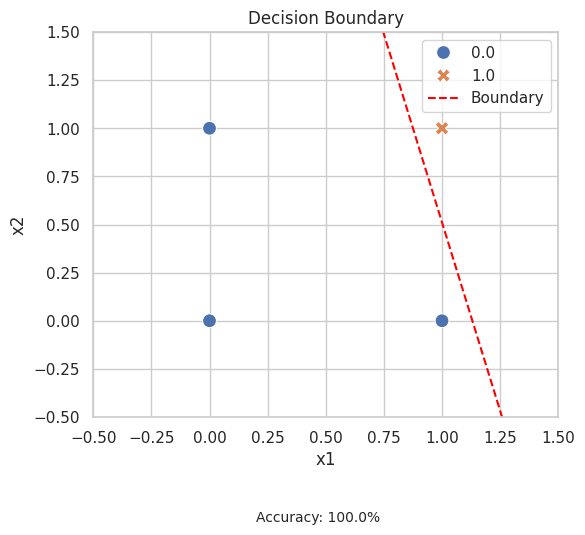

In [43]:
# ANSWER
# Re-initialize perceptron
X = torch.tensor([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
], dtype=torch.float32)

# Our target labels for each observation above
y_and = torch.tensor([0., 0., 0., 1.], dtype=torch.float32)

model = Perceptron(input_dim=2)

train_pocket_perceptron(model, X, y_and, learning_rate=0.01, epochs=100)

plot_decision_boundary(model, X, y_and)

3. Now, the big win! You are going to use your new `train_pocket_perceptron` to train individual perceptrons, passing that function as the `train_func` parameter for `train_oneVsRestPerceptron_batch`.  Show the accuracy of the dataset. This really should be a copy and paste of your code above that 1) instantiates a new OneVsRestPerceptron model, 2) calls `train_oneVsRestPerceptron_batch` but passing `train_pocket_perceptrion` for the `train_func` parameter. Then go through and output your final result. It should be quite good!

In [44]:
# ANSWER

model = OneVsRestPerceptron(input_dim=4, num_classes=3)

train_oneVsRestPerceptron_batch(model, X_iris_std, y_iris_ohe, learning_rate=0.025, epochs=50, train_func=train_pocket_perceptron)

pred = model.forward(X_iris_std)

accuracy = (pred == y_iris_ohe).float().mean() * 100

print(f"The accuracy of this model on the Iris dataset is {accuracy}%")




Starting pocket batch training...
Training parameters: learning_rate=0.025, epochs=50
Epoch 0: Total Error = 142.0, Accuracy = 5.33333346247673
Found better weights, saving to pocket
Epoch 1: Total Error = 2.0, Accuracy = 98.66666793823242
Found better weights, saving to pocket
Epoch 2: Total Error = 2.0, Accuracy = 98.66666793823242
Epoch 3: Total Error = 1.0, Accuracy = 99.33333396911621
Found better weights, saving to pocket
Epoch 4: Total Error = 1.0, Accuracy = 99.33333396911621
Epoch 5: Total Error = 0.0, Accuracy = 100.0
Found better weights, saving to pocket
Converged at epoch 5!
Restoring pocket weights and bias: tensor([-2.0049,  1.8868, -3.2493, -2.5774]); tensor([-1.2000]) with error 0.0 and accuracy 100.0
Starting pocket batch training...
Training parameters: learning_rate=0.025, epochs=50
Epoch 0: Total Error = 88.0, Accuracy = 41.333332657814026
Found better weights, saving to pocket
Epoch 1: Total Error = 78.0, Accuracy = 47.999998927116394
Found better weights, saving 

## 4. Continuous Data & The Limits of the Step Function

The step function is a bit limited. It has a derivative of 0 everywhere (except at 0, where it's undefined). This makes it impossible to use with **Gradient Descent**, which relies on gradients to guide updates. We haven't covered gradient descent yet, but you'll soon see how important differentiable functions are toward minimizing the error.

Next week, we will replace the Step function with Sigmoid or ReLU.

**Reflection Question:**
Look at your update rule: `weights += lr * error * x`.
If `error` is 0, the weights don't move.
If `error` is not 0, the weights jump significantly, depending on that learning rate.
How does this "jumpy" behavior compare to the idea of "sliding down a hill" (Gradient Descent)? Why might "sliding" be better for complex problems?

**ANSWER:**

"Sliding" might be better for complex problems because it allows for making consistent progress rather than jumping around discrete values. It helps find a local minimum for the loss/error function, meaning it can find the best approximation for problems where data might not be completely linearly separable. It also always makes small updates even when you are close to a local minimum, taking advantage of its ability to tell you how wrong you are and by how much.






In [45]:
%%html
<div class="section-box">
<h1></h1>
</div>

# <div class="section-box">Career Survey</div>

## Career Survey: Week 2 - The "Guts" vs. The "Wrapper"
In Week 1, we looked at the "AI Engineer" as a general title. This week, as you implement the Perceptron’s learning rule from scratch, we are exploring the value of Foundational ML Knowledge. So, ask yourself:

*Is it enough to just use "wrappers" as a machine learning or AI developer and simply know how to call model.fit() with Scikit-learn models, or use high-level dashboards that shield you from needing to train models, or perhaps just use a GPT-5 or similar API? Or does the 2026 market still pay a premium for those who can write the "guts" of a machine learned model, such as the training loop you wrote this week?*

1. Use your favorite LLM to research the current 2026 sentiment regarding "Foundational" vs. "Applied" AI skills. Paste the prompt you use and the AI’s response in your answer below. Or, you can use the prompt below:

**"I am learning about the "guts" of neural networks in PyTorch, including implementing my own models and training loops. I just learned about Perceptrons and will be soon learning about MLPs, deep learning, recurrent nets and more. Is this valuable in 2026? In the 2026 job market, find 3 specific reasons why a Lead AI Engineer would hire a candidate who understands 'from-scratch' implementation over a candidate who only knows how to use dashboards or pre-trained models via APIs."**

2. The "Classical" Revival: "Identify three industries (e.g., High-Frequency Trading, MedTech, Robotics, etc.) where 'Classical' Machine Learning (non-LLM architectures like MLPs, deep learning, recurrent nets like LSTMs or GRU, etc.) is still preferred over Large Language Models. Why is 'Small AI' still a big business in 2026?"

#### ANSWER:
1. I used the given prompt and got the following response:<br>

```
Yes, this is extremely valuable in 2026. Here are 3 specific reasons a Lead AI Engineer would hire you over an API-only candidate:
1. You can debug production failures that black-box users can't
When AI systems fail in production, they often fail silently with poor predictions rather than crashes, and practitioners spend 80-90% of their time debugging models. FullstackdeeplearningNeptune.ai Someone who only uses APIs has no insight into:

Why gradients are vanishing/exploding in your training pipeline
Whether your loss landscape is poorly conditioned
If your data preprocessing is causing systematic errors that the model adapts to

Common issues like shape mismatches, out-of-memory errors, and wrong tensor data types require stepping through model creation and inference step-by-step. Fullstackdeeplearning When your company's inference server starts producing garbage outputs at 3am, you'll be the one who can identify if it's a numerical stability issue, a data pipeline bug, or an architecture problem—not the person who just calls model.predict().
2. You can optimize models for your specific infrastructure constraints
Model compression, quantization, pruning, and custom architecture design are critical for deploying models under memory, power, and latency constraints. Nature The efficiency of DNN solutions depends on both the architecture and compiler-level scheduling strategy—current NAS methods overlook true-optimal implementations that can only be discovered by trying different combinations of scheduling strategies and architectures. ACM Digital Library
Given your Meta experience with database infrastructure and 99.99% SLA requirements, you understand this: when you need to serve 10,000 QPS with <50ms latency on limited GPU memory, you need someone who can:

Redesign layer implementations to reduce memory footprint
Fuse operations to minimize data movement
Profile compute vs memory bottlenecks at the kernel level

API users can't do this—they're stuck with whatever the model provider gives them.
3. You can build custom architectures for novel problems
In 2026, companies want engineers who recognize when AI makes sense in a context and when it doesn't, and can explain why AI is being used and what it contributes. UdemyCourse Report Hybrid architectures that combine different computational approaches are proliferating, with companies combining attention layers with state space models and other techniques. Adaline
Your Stellark AR/AI project for data center operations is exactly the type of domain-specific problem where off-the-shelf models won't cut it. When you need to:

Process real-time multimodal data (AR visuals + sensor data + logs)
Build custom loss functions that encode domain knowledge about data center operations
Design architectures that balance accuracy with edge device constraints

...you need to understand the fundamentals. The 2026 AI job market rewards depth and specialization, with employers expecting engineers who can deploy models, not just build them in notebooks. Futurense
Bottom line: Dashboard/API users are fine for plugging in existing solutions. But when systems break, need custom optimization, or require novel architectures—which is most real engineering work—deep understanding is irreplaceable.
```

2. 3 industries that still use traditional ML models are:
- High-frequency trading
- Retail
- Healthcare

"Small AI" is still very valuable as they are tailored for different purposes that are just inefficient/non-transferrable for LLMs.




In [46]:
%%html
<div class="section-box">
<h1></h1>
</div>

# <div class="section-box">Society</div>

## The Hype Cycle: 1958 vs. 2026

In 1958, after Frank Rosenblatt demonstrated the Perceptron, the *New York Times* ran the headline:
> **"New Navy Device Learns By Doing... The embryo of an electronic computer... expected to be able to walk, talk, see, write, reproduce itself and be conscious of its existence."**

It took 60 more years to get close to "talking" and "writing" (LLMs), and we still aren't at "conscious."

**Reflection:**
We are currently in another massive AI hype cycle. You should be regularly reading the news in tech and keeping up with the trends in our field. Assuming you do, you should be periodically seeing quite a number of articles with very different perspectives on the future of AI. On one end, you'll read about AGI and the death of all entry level jobs. On the other end, you'll read about how we [lack an infrastructure that can keep up with AI demand](https://www.deloitte.com/us/en/insights/industry/power-and-utilities/data-center-infrastructure-artificial-intelligence.html) and that we are in the midst of an AI bubble that is ready to pop. The fact is that nobody really knows what the future holds. One thing is for sure: AI in some form is here to stay.

1.  Compare the 1958 quote to a headline you've seen recently about OpenAI, Google Gemini, or AGI.
2.  The "AI Winter" of the 1970s occurred because the technology (Perceptrons) failed to live up to the impossible hype (XOR problem, compute limitations). Do you see any "walls" or limitations in current AI technology that could trigger a new AI Winter, or is this time truly different?

(Write 150-250 words).

#### ANSWER:

1. I have seen a lot of headlines arguing that AGI is nascent, but with the amount of progress that these AI companies have made, people are starting to be more skeptical about this possibility. For instance, this article by the Guardian argues that the trillions of dollars that investors have put into the race for AGI is not guaranteed to produce AGI: https://www.theguardian.com/technology/2026/jan/17/why-trillions-dollars-risk-no-guarantee-ai-reward.
2. I think that, as Yann LeCun has stated, LLMs is not the path to true AGI. However, I believe that it is a component of true AGI. I think that to reach AGI, we should look at biomimetic design, where we model the different parts of the brain. A facet that I think AGI should also exhibit is the ability to evolve or change itself over time. LLMs can change parameters through training and fine-tuning, but it is not inherently changing the way it processes information. There is no fundamental change in its logical structure.

In [47]:
%%html
<div class="section-box">
<h1></h1>
</div>

# <div class="section-box">AI Usage Disclosure</div>

**IDE or browser-based environment used:**

**AI tools used:**

**Short reflection:**
How did you use AI? Did it help you visualize the geometry of the Perceptron? Did it help you debug the manual update loop?

**AI Chat Dialogs:**
(Paste relevant snippets here)

<b>IDE</b>: VSCode with Colab

<b>AI Tools Used</b>: Claude

<b>Short Reflection</b>: I used AI to help find pytorch functions and syntax. It was not a hindrance, but it helped me save time from looking through documentation (for quick search).

<b>AI Chat Dialogues</b>:<br>
1. 
```
how to draw red circle in sns.scatterplot

4:06 PM

Weighed multiple visualization approaches for seaborn scatter customization.





Here are the main ways to draw red circles in a seaborn scatterplot:

1. Make all points red:

python
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='x_col', y='y_col', color='red')
2. Add a specific red circle annotation:

python
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Create scatterplot
ax = sns.scatterplot(data=df, x='x_col', y='y_col')

# Add red circle at specific coordinates
circle = Circle((x_position, y_position), radius=0.5, 
                color='red', fill=False, linewidth=2)
ax.add_patch(circle)
3. Highlight specific points in red:

python
# Assuming you have a condition
mask = df['category'] == 'special'

sns.scatterplot(data=df[~mask], x='x_col', y='y_col', color='blue')
sns.scatterplot(data=df[mask], x='x_col', y='y_col', color='red')
4. Use hue parameter with custom palette:

python
sns.scatterplot(data=df, x='x_col', y='y_col', 
                hue='category', palette={'A': 'blue', 'B': 'red'})
Which scenario matches what you're trying to do?
```

2.
```
what does padas.get_dummies() do? what about in terms of one-hot encoding

pandas.get_dummies() - One-Hot Encoding
It converts categorical variables into binary (0/1) columns. This IS one-hot encoding.
Example
pythonimport pandas as pd

df = pd.DataFrame({
    'color': ['red', 'blue', 'red', 'green']
})

pd.get_dummies(df['color'])
```

**Result:**
```
   blue  green  red
0     0      0    1
1     1      0    0
2     0      0    1
3     0      1    0
What happened:

Created 3 new columns (one per unique value)
Each row has a 1 in the column matching its original value
All other columns get 0

Why One-Hot Encoding?
Problem: Machine learning models need numeric inputs, but categorical data like 'red', 'blue', 'green' isn't inherently numeric.
Bad solution: Just map to integers (red=0, blue=1, green=2)

Implies ordering: green > blue > red
Implies distance: green - red = 2

Good solution: One-hot encoding

No false ordering or relationships
Each category is independent

Common Usage
python# On entire DataFrame (auto-detects categorical columns)
df_encoded = pd.get_dummies(df)

# With prefix for clarity
pd.get_dummies(df['color'], prefix='color')
# Result: color_red, color_blue, color_green columns

# Drop first to avoid multicollinearity (for regression)
pd.get_dummies(df['color'], drop_first=True)
# Only creates: blue, green (red is implied when both are 0)
Bottom line: get_dummies() = pandas' built-in one-hot encoder. Transforms categorical text/labels into binary columns that models can use.
```

In [52]:
tensor = torch.randn(1)
print(tensor.device)
print(torch.accelerator.is_available())
print(torch.accelerator.current_accelerator())
tensor = tensor.to(torch.accelerator.current_accelerator())
print(tensor.device)

cpu
True
cuda
cuda:0
